In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import sqlite3
import os
from tqdm import tqdm
sns.set_theme(style="darkgrid", palette="Set2")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.usetex": True
})

os.environ["PATH"] = os.path.expanduser("~/texlive2025/bin/x86_64-linux") + os.pathsep + os.environ.get("PATH", "")



In [3]:
def combine_results_all(max_num_jobs, types, db_path="results.sqlite", results_dir="results", chunksize=100000):
    if os.path.exists(db_path):
        os.remove(db_path)
    for type in tqdm(types):
        for with_clone in ["_with_clone", "_without_clone"]:
            for postfix in ["", "_yrwr"]:
                combine_results(max_num_jobs, f"{type}{postfix}{with_clone}", db_path, results_dir, if_exists="append", chunksize=chunksize)

        combine_results(max_num_jobs, f"{type}_kt_distance_with_clone", db_path, results_dir, if_exists="append", chunksize=chunksize)
        combine_results(max_num_jobs, f"{type}_kt_distance_yrwr_with_clone", db_path, results_dir, if_exists="append", chunksize=chunksize)
        combine_results(max_num_jobs, f"{type}_order_violations", db_path, results_dir, if_exists="append", chunksize=chunksize)
        combine_results(max_num_jobs, f"{type}_kt_distance_bw_mechanisms", db_path, results_dir, if_exists="append", chunksize=chunksize)



def combine_results(max_num_jobs, table, db_path="results.sqlite", results_dir="results", if_exists="replace", chunksize=100000):
    with sqlite3.connect(db_path) as out_conn:
        wrote_any = False

        for i in range(max_num_jobs):
            in_path = f"{results_dir}/job_{i}.sqlite"
            if not os.path.exists(in_path):
                continue
            with sqlite3.connect(in_path) as in_conn:
                try:
                    for chunk in pd.read_sql(f"SELECT * FROM {table}", in_conn, chunksize=chunksize):
                        mode = if_exists if not wrote_any else "append"
                        chunk.to_sql(table, out_conn, if_exists=mode, index=False)
                        wrote_any = True
                except pd.errors.DatabaseError:
                    print(f"Error reading {table} for job {i}")

def plot_modalities(df, ax, title):
    sns.lineplot(data=df, ax=ax, palette="plasma", dashes=False, marker="o")
    ax.set_title(title)
    ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_xticks(range(1, 6))

def plot_rank_differences(df_with_clone, df_without_clone, ax, title):
    diff = df_without_clone.mean() - df_with_clone.groupby("num_clones").mean()
    plot_modalities(diff, ax, title)

def plot_ranks(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    model_names = list(df.index)
    sns.boxplot(data=df, ax=ax)
    ax.set_xlabel("Model")
    ax.set_ylabel("Rank")
    ax.set_xticklabels(model_names, rotation=90)
    plt.show()

def load_all(table, db_path="results.sqlite"):
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql(f"SELECT * FROM {table}", conn)

def get_model_org_dicts(typ):
    df = pd.read_csv(f"parsed_tables/{typ}.csv", index_col="Model")

    alpha = 400 / math.log(10)
    true_abilities = (df['Score'] - 1000) / alpha # convert to unscaled abilities
    M = len(true_abilities)
    model_names = list(true_abilities.index)

    org_to_models = (
        df.reset_index()
            .sort_values('Score', ascending=False)
            .groupby('Organization')['Model']
            .apply(lambda models: [model_names.index(m) for m in models])
            .to_dict()
    )
    model_to_org = df.reset_index().set_index("Model")["Organization"].to_dict()
    return model_to_org, org_to_models, model_names

In [4]:
# TYPES = ["coding", "ahp", "image-edit", "text", "text-to-image", "text-to-video", "vision", "webdev"]
top_level_types = ["vision","text_coding", "webdev", "texttoimage", "imageedit", "imagetovideo"]
occuptationals = ["text_occupational_" + t for t in ["business", "entertainment", "legal", "life_physical_social_science", "mathematical", "software_it_services", "writing_literature", "medicine"]]
text_categories = ["text_" + t for t in ["expert", "hard_prompts", "instruction_following", "longer_query", "multiturn"]]
# vision_categories = ["vision_" + t for t in ["captioning", "diagram", "ocr"]]
TYPES = ["text"] + text_categories + top_level_types 

# TYPES = ["imageedit", "imagetovideo"]

TYPES_WITHOUT_DASHES = [t.replace("-", "") for t in TYPES]
n_jobs = 100



In [ ]:
combine_results_all(n_jobs, TYPES_WITHOUT_DASHES, results_dir="results")

with sqlite3.connect("results.sqlite") as conn:
    cursor = conn.cursor()
    tables = cursor.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
    print("Tables in the database:", [t[0] for t in tables])

In [5]:
TYPE_NAMES = {
    "text": "Text",
    "vision": "Vision",
    "text_coding": "Coding",
    "webdev": "Web Development",
    "texttoimage": "Text to Image",
    "imageedit": "Image Edit",
    "search": "Search",
    "imagetovideo": "Image to Video",
    "text_creative_writing": "Creative Writing",
    "text_expert": "Expert",
    "text_hard_prompts": "Hard Prompts",
    "text_instruction_following": "Instruction Following",
    "text_longer_query": "Longer Query",
    "text_multiturn": "Multiturn",
    "text_occupational_business": "Occupational: Business",
    "text_occupational_entertainment": "Occupational: Entertainment",
    "text_occupational_legal": "Occupational: Legal",
    "text_occupational_life_physical_social_science": "Occupational: Life, Physical, Social Science",
    "text_occupational_mathematical": "Occupational: Mathematical",
    "text_occupational_software_it_services": "Occupational: Software, IT Services",
    "text_occupational_writing_literature": "Occupational: Writing, Literature",
    "text_occupational_medicine": "Occupational: Medicine",
    "vision_captioning": "Captioning",
    "vision_diagram": "Diagram",
    "vision_ocr": "OCR",
}

In [6]:
df_with_clone = {}
df_without_clone = {}
df_yrwr_with_clone = {}
df_yrwr_without_clone = {}
df_kt_distance_with_clone = {}
df_kt_distance_yrwr_with_clone = {}
df_order_violations = {}
df_kt_dist_bw_mechanisms = {}
for type in TYPES_WITHOUT_DASHES:
    TABLE_WITH_CLONE = f"{type}_with_clone"
    TABLE_WITHOUT_CLONE = f"{type}_without_clone"
    TABLE_YRWR_WITH_CLONE = f"{type}_yrwr_with_clone"
    TABLE_YRWR_WITHOUT_CLONE = f"{type}_yrwr_without_clone"
    TABLE_KT_DISTANCE_WITH_CLONE = f"{type}_kt_distance_with_clone"
    TABLE_KT_DISTANCE_YRWR_WITH_CLONE = f"{type}_kt_distance_yrwr_with_clone"
    TABLE_ORDER_VIOLATIONS = f"{type}_order_violations"
    TABLE_KT_DISTANCE_BW_MECHANISMS = f"{type}_kt_distance_bw_mechanisms"
    df_with_clone[type] = load_all(TABLE_WITH_CLONE)
    df_without_clone[type] = load_all(TABLE_WITHOUT_CLONE)
    df_yrwr_with_clone[type] = load_all(TABLE_YRWR_WITH_CLONE)
    df_yrwr_without_clone[type] = load_all(TABLE_YRWR_WITHOUT_CLONE)
    df_kt_distance_with_clone[type] = load_all(TABLE_KT_DISTANCE_WITH_CLONE)
    df_kt_distance_yrwr_with_clone[type] = load_all(TABLE_KT_DISTANCE_YRWR_WITH_CLONE)
    # df_order_violations[type] = load_all(TABLE_ORDER_VIOLATIONS)
    df_kt_dist_bw_mechanisms[type] = load_all(TABLE_KT_DISTANCE_BW_MECHANISMS)

In [7]:
mean_num_votes = {}
for typ in TYPES_WITHOUT_DASHES:
    parsed_df = pd.read_csv(f"parsed_tables/{typ}.csv")
    n_models = len(parsed_df)
    mean_num_votes[typ] = 2 * parsed_df['Votes'].sum() / (n_models * (n_models - 1))

mean_num_votes_df = pd.DataFrame(mean_num_votes.items(), columns=['Type', 'Mean Number of Votes'])
mean_num_votes_df


,Type,Mean Number of Votes
0,text,173.278625
1,text_expert,12.151117
2,text_hard_prompts,58.513161
3,text_instruction_following,56.553369
4,text_longer_query,29.097922
5,text_multiturn,28.442640
6,vision,237.755873
7,text_coding,30.439518
8,webdev,265.762923
9,texttoimage,8689.692192


In [7]:
rows = []
for typ in TYPES_WITHOUT_DASHES:
    n_models = len(df_with_clone[typ].columns)
    total_num_simulations = 3 * 5 * 48 * n_models
    num_violations = len(df_order_violations[typ])
    p_violation = num_violations / total_num_simulations
    se_p_violation = np.sqrt(p_violation * (1 - p_violation) / total_num_simulations)
    rows.append({
        "Type": TYPE_NAMES[typ],
        "Percent Violations": f"{100*p_violation:.2f} ({100*se_p_violation:.2f})"
    })

violations_df = pd.DataFrame(rows)
# print(violations_df.to_latex(index=False, escape=False))
violations_df

/tmp/ipykernel_1132717/327102792.py:7: RuntimeWarning: invalid value encountered in sqrt
  se_p_violation = np.sqrt(p_violation * (1 - p_violation) / total_num_simulations)


,Type,Percent Violations
0,Text,4762.44 (nan)
1,Expert,3709.54 (nan)
2,Hard Prompts,4656.58 (nan)
3,Instruction Following,4573.34 (nan)
4,Longer Query,4247.35 (nan)
5,Multiturn,4422.79 (nan)
6,Vision,1398.07 (nan)
7,Coding,4480.64 (nan)
8,Web Development,446.12 (nan)
9,Text to Image,538.84 (nan)


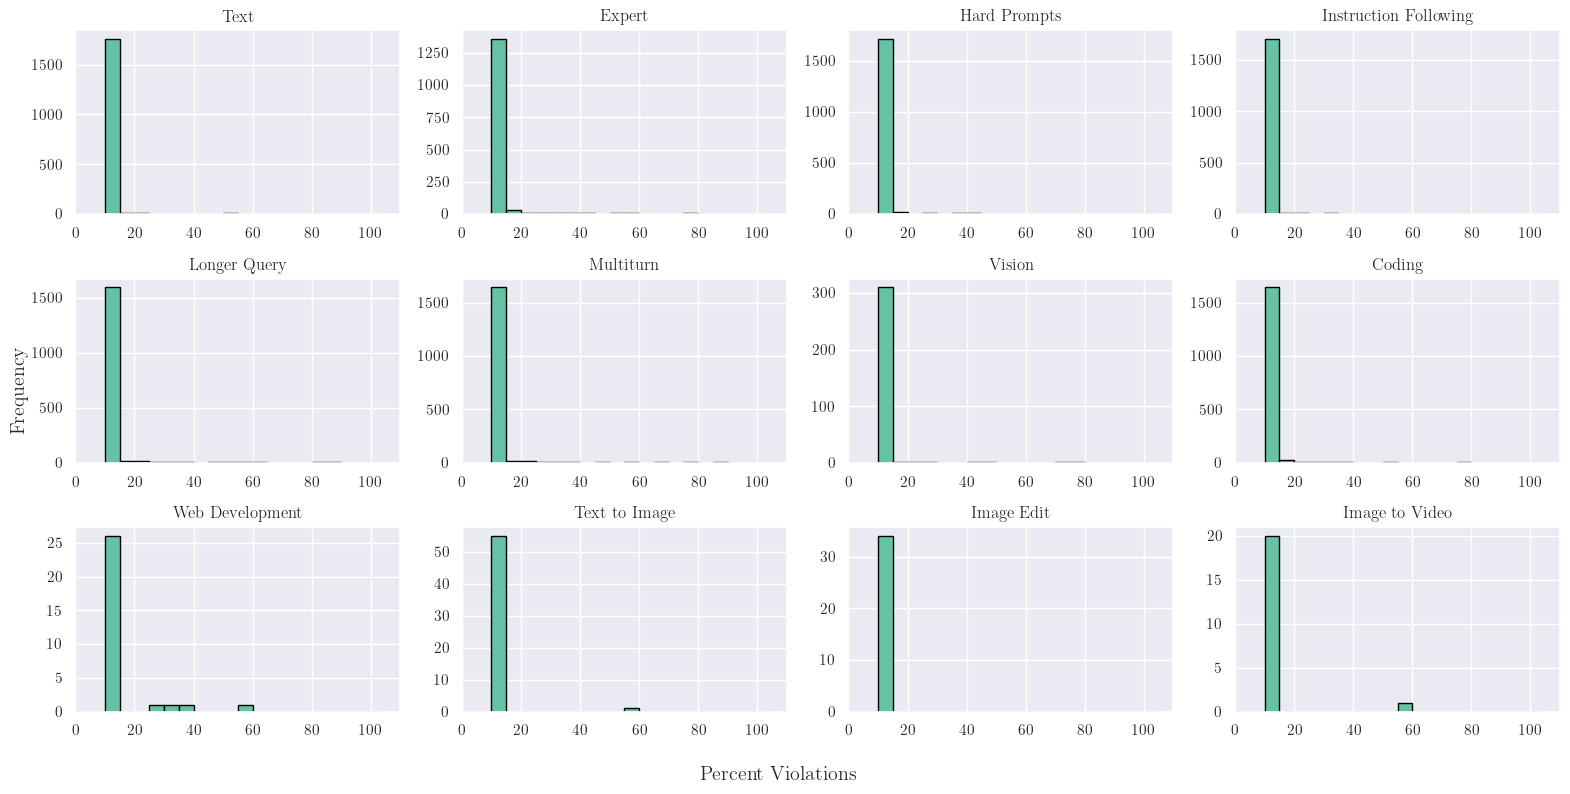

In [8]:
B = 3
max_num_clones = 5
n_jobs = 100
sims_per_pair = B * max_num_clones * n_jobs

n_modalities = len(df_with_clone.values())

fig, axes = plt.subplots(n_modalities // 4, 4, figsize=(16, 8))
# fig, axes = plt.subplots(2, 2, figsize=(6, 3.5))

for i, typ in enumerate(TYPES_WITHOUT_DASHES):
    grouped = df_order_violations[typ].groupby(['model_ahead', 'model_to_clone']).size().reset_index(name='count')
    grouped['percent_violations'] = 100 * grouped['count'] / sims_per_pair

    bins = np.arange(0, 110, 5)
    axes[i // 4, i % 4].hist(grouped['percent_violations'], bins=bins, edgecolor='black')
    axes[i // 4, i % 4].set_title(f'{TYPE_NAMES[typ]}')
    axes[i // 4, i % 4].set_xlim(0, 110)

fig.supxlabel('Percent Violations')
fig.supylabel('Frequency')
plt.tight_layout()
plt.show()

In [9]:
typ = 'text'
model_to_org, org_to_models, model_names = get_model_org_dicts(typ)
grouped = df_order_violations[typ].groupby(['model_ahead', 'model_to_clone']).size().reset_index(name='count')
grouped['percent_violations'] = 100 * grouped['count'] / sims_per_pair
high_violations = grouped[grouped['percent_violations'] > 40]
high_violations_named = high_violations.copy()
high_violations_named['organization'] = high_violations_named['model_to_clone'].apply(lambda idx: model_to_org[model_names[idx]])
high_violations_named['model_to_clone'] = high_violations_named['model_to_clone'].apply(lambda idx: model_names[idx])
high_violations_named = high_violations_named.rename(columns={'model_to_clone': 'model_behind'})
high_violations_named['model_ahead'] = high_violations_named['model_ahead'].apply(lambda idx: model_names[idx])

print(high_violations_named[['model_ahead', 'model_behind', 'percent_violations']].to_string(index=False))

                                      model_ahead                                      model_behind  percent_violations
                                     gemini-3-pro                                    gemini-3-flash         2939.933333
                                   gemini-3-flash                 gemini-3-flash (thinking-minimal)         2939.933333
                                grok-4.1-thinking                                          grok-4.1         2940.000000
   Anthropicclaude-opus-4-5-20251101-thinking-32k                 Anthropicclaude-opus-4-5-20251101         2606.466667
   Anthropicclaude-opus-4-5-20251101-thinking-32k  Anthropicclaude-sonnet-4-5-20250929-thinking-32k          340.000000
                Anthropicclaude-opus-4-5-20251101  Anthropicclaude-sonnet-4-5-20250929-thinking-32k         2610.000000
                                         grok-4.1                           grok-4-1-fast-reasoning         2940.000000
                gemini-3-flash (thinking

In [10]:
typ = 'vision'
model_to_org, org_to_models, model_names = get_model_org_dicts(typ)
grouped = df_order_violations[typ].groupby(['model_ahead', 'model_to_clone']).size().reset_index(name='count')
grouped['percent_violations'] = 100 * grouped['count'] / sims_per_pair
high_violations = grouped[grouped['percent_violations'] > 40]
high_violations_named = high_violations.copy()
high_violations_named['organization'] = high_violations_named['model_to_clone'].apply(lambda idx: model_to_org[model_names[idx]])
high_violations_named['model_to_clone'] = high_violations_named['model_to_clone'].apply(lambda idx: model_names[idx])
high_violations_named['model_ahead'] = high_violations_named['model_ahead'].apply(lambda idx: model_names[idx])

print(high_violations_named[['model_ahead', 'model_to_clone', 'percent_violations']].to_string(index=False))

                                      model_ahead                    model_to_clone  percent_violations
                                          gpt-5.1        chatgpt-4o-latest-20250326           41.944444
                       gpt-4.5-preview-2025-02-27                        gpt-5-chat           40.694444
                                    o3-2025-04-16                gpt-4.1-2025-04-14           60.000000
                          gpt-4.1-mini-2025-04-14                o4-mini-2025-04-16          100.555556
                  Anthropicclaude-opus-4-20250514 Anthropicclaude-sonnet-4-20250514           59.305556
gemini-2.5-flash-lite-preview-09-2025-no-thinking                gemini-1.5-pro-002          105.972222
                                     qwen2-vl-72b                  qwen-vl-max-1119          105.138889
                            amazon-nova-lite-v1.0              amazon-nova-pro-v1.0          102.500000


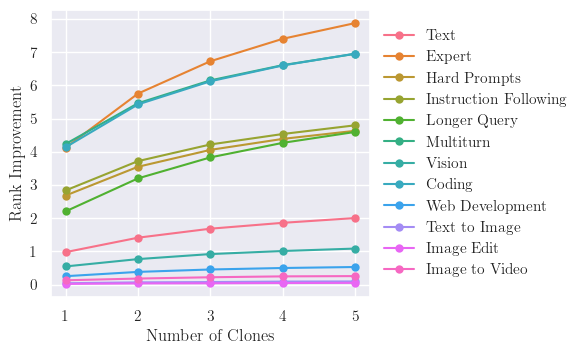

In [39]:
fig, ax = plt.subplots(figsize=(6, 3.7))

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
# means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    means[type] = (df_without_clone[type].mean() - df_with_clone[type].groupby("num_clones").mean()).mean(axis=1)
    # means_yrwr[type] = (df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type].groupby("num_clones").mean()).mean(axis=1)

sns.lineplot(data=means, dashes=False, marker="o", markeredgewidth=0, ax=ax, palette=sns.color_palette("husl", len(TYPES_WITHOUT_DASHES)))

# ax.set_ylim(-0.1, 10)
ax.set_xlabel("Number of Clones")
ax.set_ylabel("Rank Improvement")
ax.set_xticks(range(1, 6))

ax.get_legend().remove()

handles, old_labels = ax.get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]
ax.legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
plt.tight_layout()
plt.savefig("plots/rank_difference.png", dpi=500)

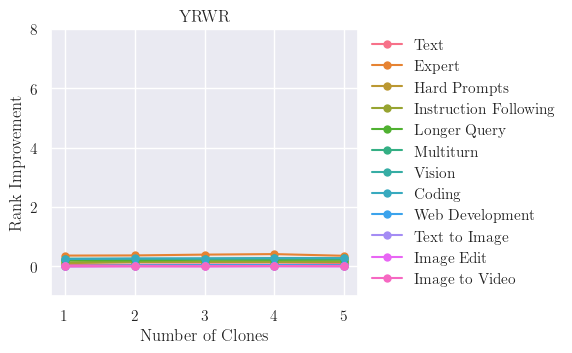

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 3.7))

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    means_yrwr[type] = (df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type].groupby("num_clones").mean()).mean(axis=1)

sns.lineplot(data=means_yrwr, dashes=False, marker="o", markeredgewidth=0, ax=ax, palette=sns.color_palette("husl", len(TYPES_WITHOUT_DASHES)))

ax.set_ylim(-1, 8)

ax.set_xlabel("Number of Clones")
ax.set_ylabel("Rank Improvement")
ax.set_xticks(range(1, 6))
ax.get_legend().remove()

ax.set_title("YRWR")

handles, old_labels = ax.get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]
ax.legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
plt.tight_layout()
plt.savefig("plots/rank_difference_yrwr.png", dpi=500)

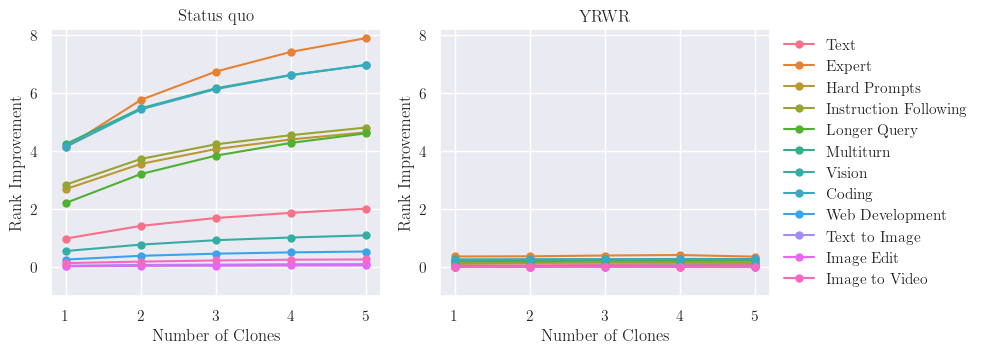

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3.7))

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    means[type] = (df_without_clone[type].mean() - df_with_clone[type].groupby("num_clones").mean()).mean(axis=1)
    means_yrwr[type] = (df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type].groupby("num_clones").mean()).mean(axis=1)

sns.lineplot(data=means, dashes=False, marker="o", markeredgewidth=0, ax=axes[0], palette=sns.color_palette("husl", len(TYPES_WITHOUT_DASHES)))
sns.lineplot(data=means_yrwr, dashes=False, marker="o", markeredgewidth=0, ax=axes[1], palette=sns.color_palette("husl", len(TYPES_WITHOUT_DASHES)))

axes[0].set_ylim(-1, 8.2)
axes[1].set_ylim(-1, 8.2)

for ax in axes:
    ax.set_xlabel("Number of Clones")
    ax.set_ylabel("Rank Improvement")
    ax.set_xticks(range(1, 6))
    ax.get_legend().remove()

axes[0].set_title("Status quo")
axes[1].set_title("YRWR")

handles, old_labels = axes[0].get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]
axes[1].legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
plt.tight_layout()
plt.savefig("plots/rank_difference_contrast.png", dpi=500)

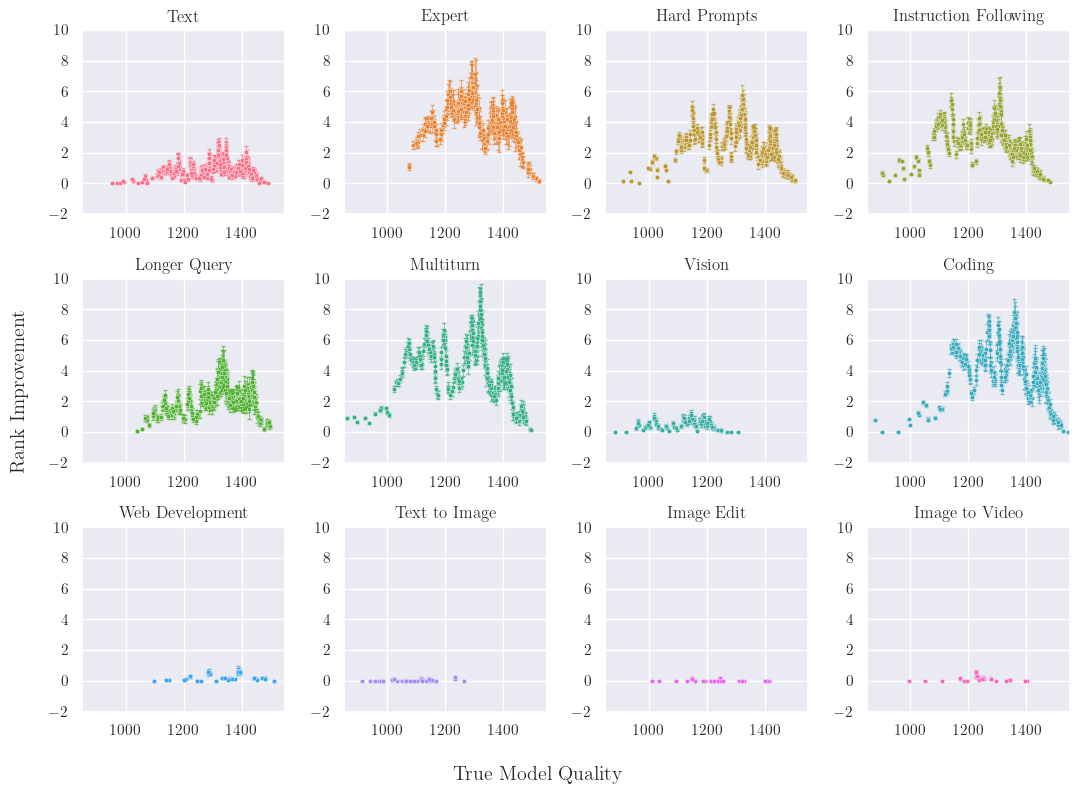

In [41]:
n_modalities = len(TYPES_WITHOUT_DASHES)
fig, axes = plt.subplots(nrows=n_modalities // 4, ncols=4, figsize=(3.7 * n_modalities // 4, 8 ))


max_rank = 300
num_clones = 1

means = {}
sds = {}
means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
merged = {}
for type in TYPES_WITHOUT_DASHES:
    parsed_df = pd.read_csv(f"parsed_tables/{type}.csv")
    means[type] = pd.Series((df_without_clone[type].mean() - df_with_clone[type][df_with_clone[type]["num_clones"] == num_clones].mean())[:max_rank])
    sds[type] = pd.Series(((df_without_clone[type] - df_with_clone[type][df_with_clone[type]["num_clones"] == num_clones]).std())[:max_rank])
    means_df = pd.DataFrame({"mean": means[type], "sd": sds[type]})
    merged[type] = pd.merge(
        means_df,
        parsed_df[["Model", "Score"]],
        left_index=True,
        right_on="Model",
        how="inner"
    )[[ "mean", "sd", "Score" ]]

palette = sns.color_palette("husl", len(TYPES_WITHOUT_DASHES))

for i, type in enumerate(TYPES_WITHOUT_DASHES):
    # Add 95% confidence intervals as error bars to each point

    num_simulations = len(df_without_clone[type])
    # If not, set n to the number of samples used per mean estimation
    ci_lo = merged[type]["mean"] - norm.ppf(0.975) * merged[type]["sd"] / np.sqrt(num_simulations)
    ci_hi = merged[type]["mean"] + norm.ppf(0.975) * merged[type]["sd"] / np.sqrt(num_simulations)

    # Plot errorbars before scatter for visibility
    axes[i//4, i%4].errorbar(
        merged[type]["Score"],
        merged[type]["mean"],
        yerr=[merged[type]["mean"] - ci_lo, ci_hi - merged[type]["mean"]],
        fmt='none',
        ecolor=palette[i],
        elinewidth=0.6,
        capsize=1.5,
        alpha=0.7,
        zorder=1
    )
    sns.scatterplot(x=merged[type]["Score"], y=merged[type]["mean"], ax=axes[i//4, i%4], color=palette[i], s=10)
    axes[i//4, i%4].set_title(TYPE_NAMES[type])
    axes[i//4, i%4].set_xlabel('')
    axes[i//4, i%4].set_ylabel('')
    axes[i//4, i%4].set_xlim(850, 1550)
    axes[i//4, i%4].set_ylim(-2, 10)

fig.supxlabel("True Model Quality")
fig.supylabel("Rank Improvement")
# fig.suptitle(f"Number of clones = {num_clones}")

plt.tight_layout()
plt.savefig(f"plots/rank_difference_by_quality_{num_clones}.png", dpi=500)

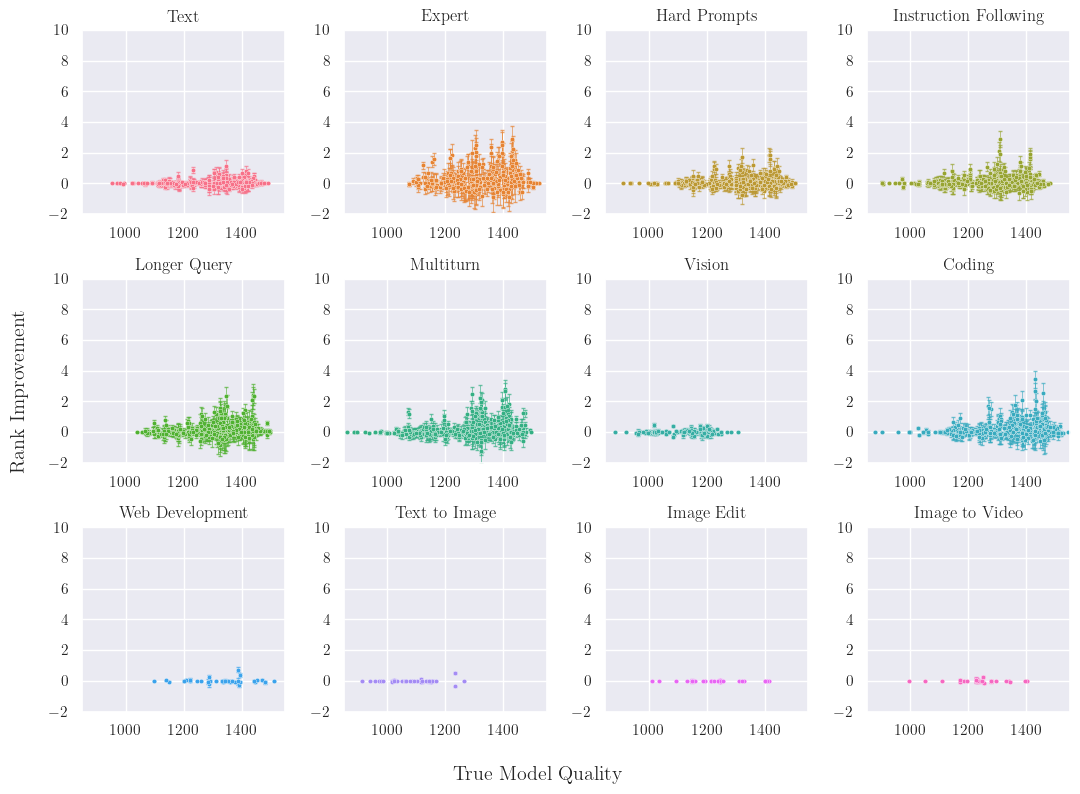

In [42]:
n_modalities = len(TYPES_WITHOUT_DASHES)
fig, axes = plt.subplots(nrows=n_modalities // 4, ncols=4, figsize=(3.7 * n_modalities // 4, 8 ))


max_rank = 300
num_clones = 1

means = {}
sds = {}
means_yrwr = {} 
merged = {}
for type in TYPES_WITHOUT_DASHES:
    parsed_df = pd.read_csv(f"parsed_tables/{type}.csv")
    means[type] = pd.Series((df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type][df_yrwr_with_clone[type]["num_clones"] == num_clones].mean())[:max_rank])
    sds[type] = pd.Series(((df_yrwr_without_clone[type] - df_yrwr_with_clone[type][df_yrwr_with_clone[type]["num_clones"] == num_clones]).std())[:max_rank])
    means_df = pd.DataFrame({"mean": means[type], "sd": sds[type]})
    merged[type] = pd.merge(
        means_df,
        parsed_df[["Model", "Score"]],
        left_index=True,
        right_on="Model",
        how="inner"
    )[[ "mean", "sd", "Score" ]]

palette = sns.color_palette("husl", len(TYPES_WITHOUT_DASHES))

for i, type in enumerate(TYPES_WITHOUT_DASHES):
    # Add 95% confidence intervals as error bars to each point
    num_simulations = len(df_yrwr_without_clone[type])
    ci_lo = merged[type]["mean"] - norm.ppf(0.975) * merged[type]["sd"] / np.sqrt(num_simulations)
    ci_hi = merged[type]["mean"] + norm.ppf(0.975) * merged[type]["sd"] / np.sqrt(num_simulations)

    # Plot errorbars before scatter for visibility
    axes[i//4, i%4].errorbar(
        merged[type]["Score"],
        merged[type]["mean"],
        yerr=[merged[type]["mean"] - ci_lo, ci_hi - merged[type]["mean"]],
        fmt='none',
        ecolor=palette[i],
        elinewidth=0.6,
        capsize=1.5,
        alpha=0.7,
        zorder=1
    )
    sns.scatterplot(x=merged[type]["Score"], y=merged[type]["mean"], ax=axes[i//4, i%4], color=palette[i], s=10)
    axes[i//4, i%4].set_title(TYPE_NAMES[type])
    axes[i//4, i%4].set_xlabel('')
    axes[i//4, i%4].set_ylabel('')
    axes[i//4, i%4].set_xlim(850, 1550)
    axes[i//4, i%4].set_ylim(-2, 10)

fig.supxlabel("True Model Quality")
fig.supylabel("Rank Improvement")
# fig.suptitle(f"Number of clones = {num_clones}")

plt.tight_layout()
plt.savefig(f"plots/rank_difference_by_quality_{num_clones}_yrwr.png", dpi=500)

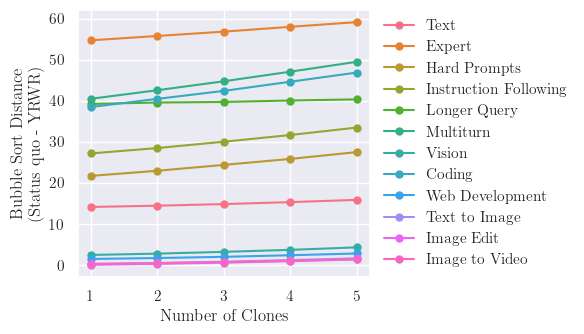

In [36]:
fig, ax = plt.subplots(figsize=(6, 3.5))

def kt_corr_to_kt_distance(kt_corr, M):
    return (1 - kt_corr) * M * (M-1) / 4

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    M = len(df_kt_distance_yrwr_with_clone[type].columns)
    means[type] = (kt_corr_to_kt_distance(df_kt_distance_with_clone[type].groupby("num_clones").mean(), M) - kt_corr_to_kt_distance(df_kt_distance_yrwr_with_clone[type].groupby("num_clones").mean(), M)).mean(axis=1)


sns.lineplot(data=means, dashes=False, marker="o", ax=ax, markeredgewidth=0, palette=sns.color_palette("husl", len(TYPES_WITHOUT_DASHES)))
# ax.set_yscale("log", base=2)

ax.set_xlabel("Number of Clones")
ax.set_ylabel("Bubble Sort Distance\n(Status quo - YRWR)")
ax.set_xticks(range(1, 6))
handles, old_labels = ax.get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]
ax.legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
plt.tight_layout()
plt.savefig("plots/bubble_sort_distance.png", dpi=500)

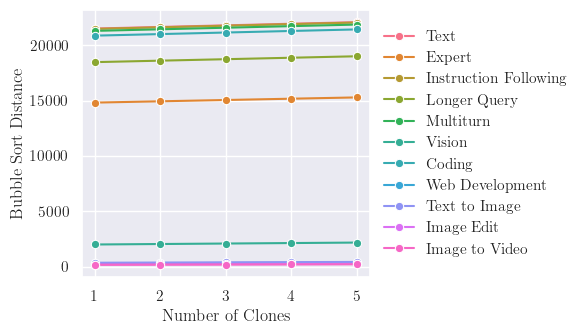

In [34]:
fig, ax = plt.subplots(figsize=(6, 3.5))

means = {}
sds = {}
for type in TYPES_WITHOUT_DASHES:
    if type == "text_hard_prompts":
        continue
    M = len(df_kt_dist_bw_mechanisms[type].columns)
    means[type] = df_kt_dist_bw_mechanisms[type].apply(pd.to_numeric, errors='coerce').groupby("num_clones").mean().mean(axis=1)
    # sds[type] = df_kt_dist_bw_mechanisms[type][""].std(axis=1)

sns.lineplot(data=means, dashes=False, marker="o", ax=ax)
# ax.set_yscale("log", base=2)

ax.set_xlabel("Number of Clones")
ax.set_ylabel("Bubble Sort Distance")
ax.set_xticks(range(1, 6))
handles, old_labels = ax.get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.keys()]
ax.legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
# ax.set_ylim(-.1, 1)
plt.tight_layout()
plt.savefig("plots/bubble_sort_distance_between_mechanisms.png", dpi=500)

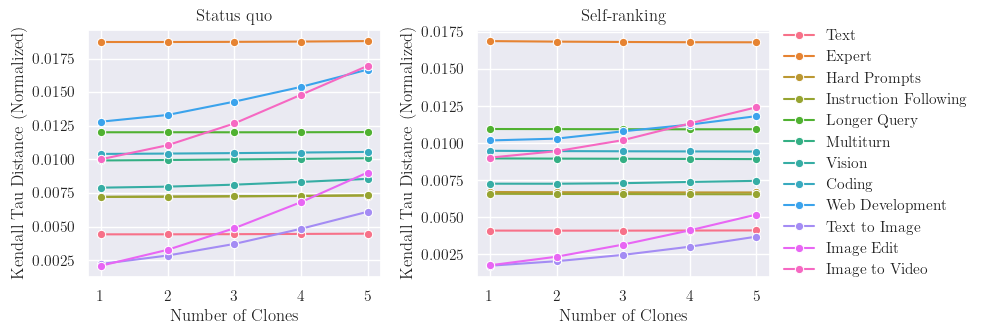

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3.5))

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
yrwr_means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    M = len(df_kt_distance_yrwr_with_clone[type].columns)
    # means[type] = (df_kt_distance_yrwr_with_clone[type].groupby("num_clones").mean() - df_kt_distance_with_clone[type].groupby("num_clones").mean()).mean(axis=1) * M * (M-1) / 2
    means[type] = (kt_corr_to_kt_distance(df_kt_distance_with_clone[type].groupby("num_clones").mean(), M)).mean(axis=1) / (M * (M-1) / 2)
    yrwr_means[type] = (kt_corr_to_kt_distance(df_kt_distance_yrwr_with_clone[type].groupby("num_clones").mean(), M)).mean(axis=1) / (M * (M-1) / 2)


sns.lineplot(data=means, dashes=False, marker="o", ax=axes[0])
sns.lineplot(data=yrwr_means, dashes=False, marker="o", ax=axes[1])
# ax.set_yscale("log", base=2)

for ax in axes:
    ax.set_xlabel("Number of Clones")
    ax.set_ylabel("Kendall Tau Distance (Normalized)")
    ax.set_xticks(range(1, 6))
    ax.get_legend().remove()

handles, old_labels = axes[0].get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]

axes[1].legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
axes[0].set_title("Status quo")
axes[1].set_title("Self-ranking")
plt.tight_layout()
plt.savefig("plots/bubble_sort_distance_double.png", dpi=500)


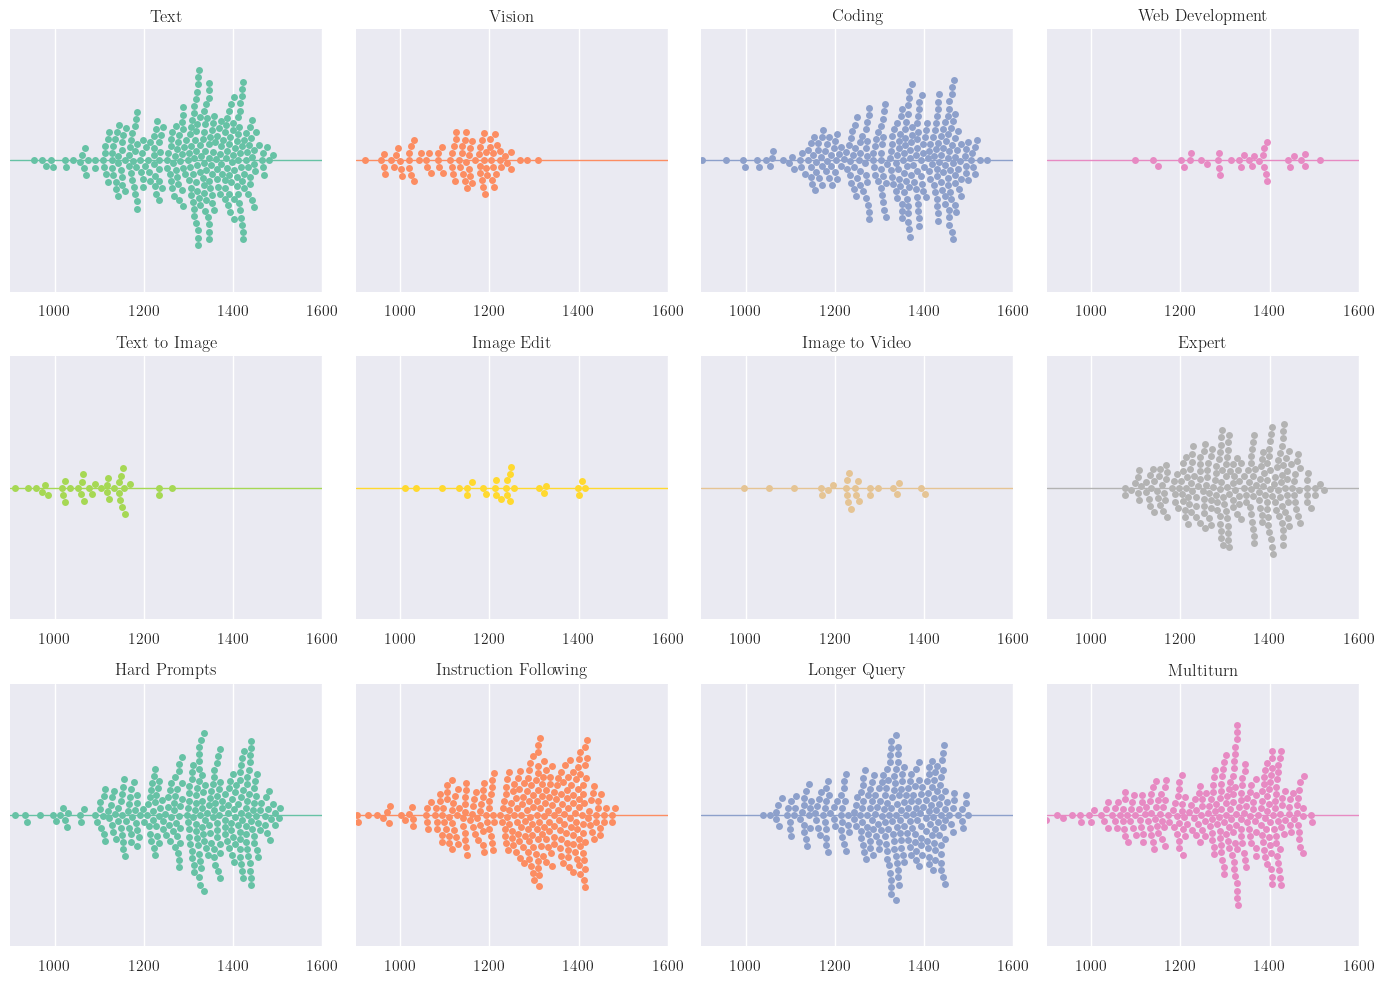

In [17]:
scores_dfs = {}
for type in TYPES_WITHOUT_DASHES:
    df = pd.read_csv(f"parsed_tables/{type}.csv")
    scores_dfs[type] = df

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 10))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    sns.swarmplot(
        data=scores_dfs[type],
        x="Score",
        alpha=1,
        size=5,
        ax=axes[i//4, i%4],
        color=f"C{i}"
    )
    axes[i//4, i%4].axhline(y=0, lw=1, color=f"C{i}")
    axes[i//4, i%4].set_title(TYPE_NAMES[type])
    axes[i//4, i%4].set(yticks=[], ylabel="")
    axes[i//4, i%4].set_xlim(900, 1600)
    axes[i//4, i%4].set_yticks([])
    axes[i//4, i%4].set_xlabel("")
    axes[i//4, i%4].set_ylabel("")
for ax_row in axes:
    for ax in (ax_row if isinstance(ax_row, (list, np.ndarray)) else [ax_row]):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

# Make unused axes (if any) invisible
for ax_row in axes:
    for ax in (ax_row if isinstance(ax_row, (list, np.ndarray)) else [ax_row]):
        if not ax.has_data():
            ax.set_visible(False)

plt.tight_layout()
plt.show()

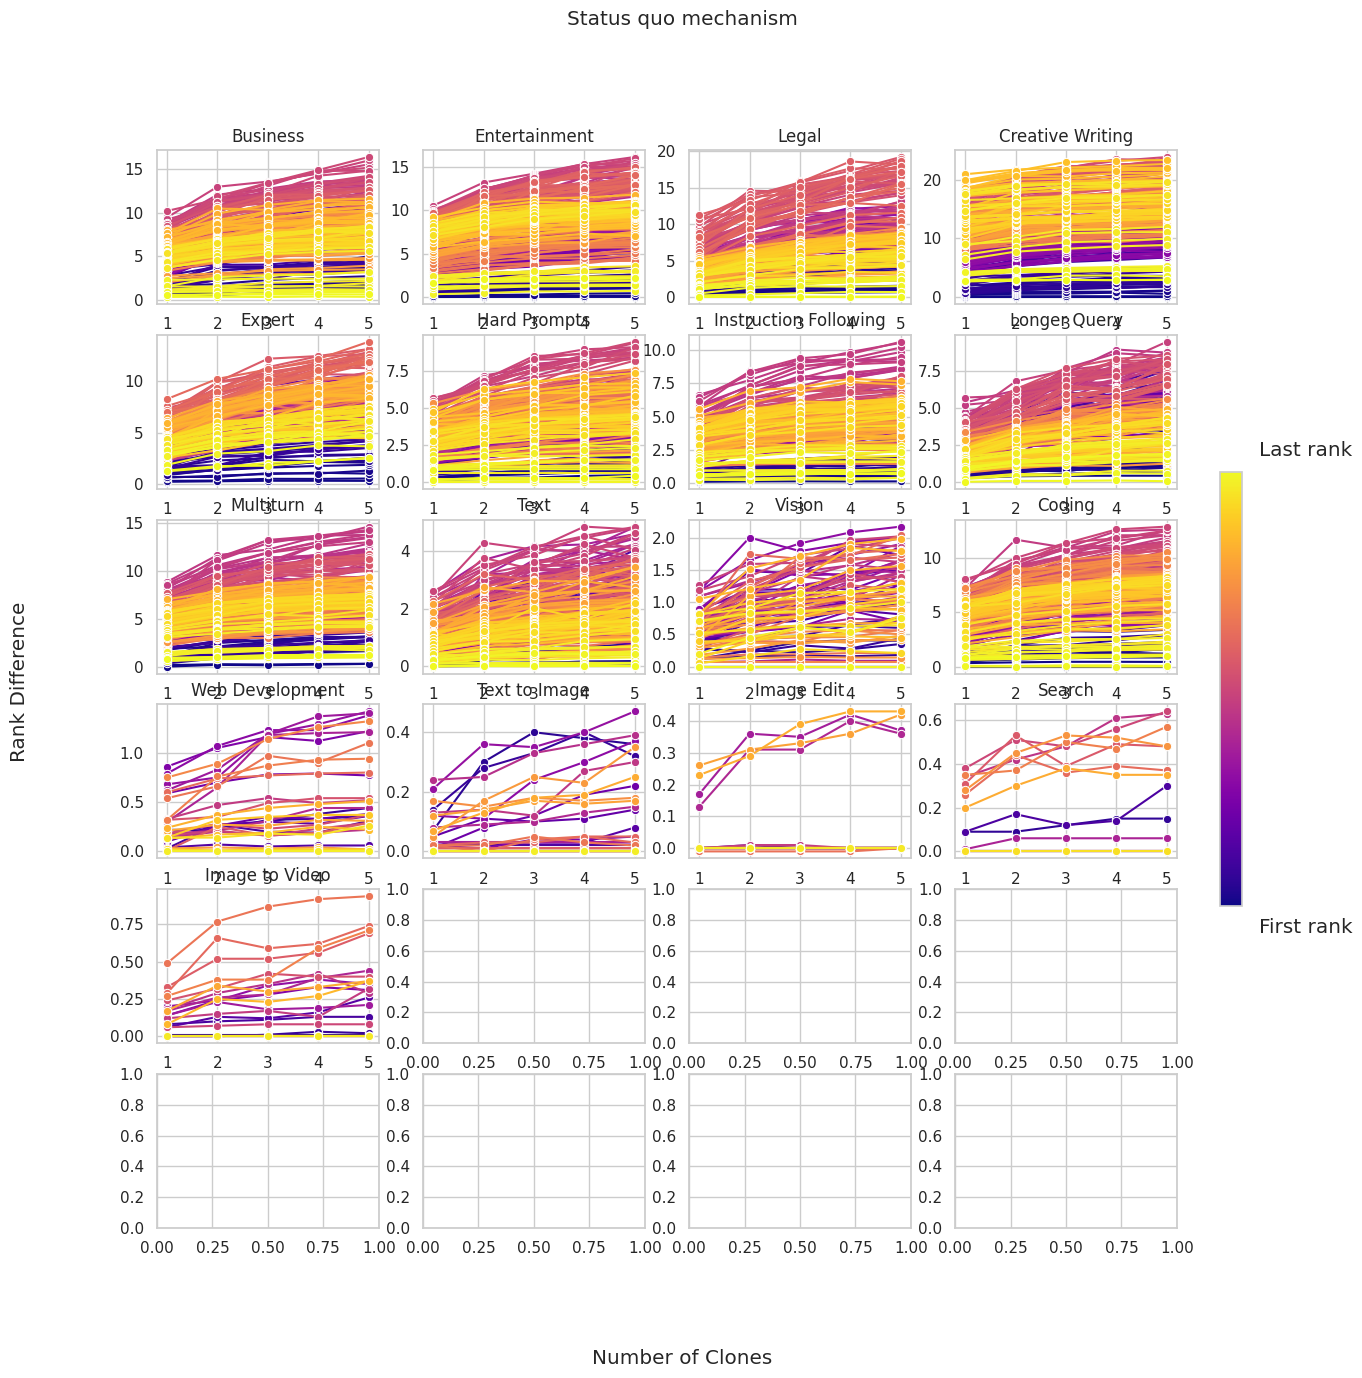

In [15]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(14, 14))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    plot_rank_differences(df_with_clone[type], df_without_clone[type], axes[i//4, i%4], TYPE_NAMES[type])

fig.supxlabel("Number of Clones")
fig.supylabel("Rank Difference")
fig.suptitle("Status quo mechanism")
# axes[0, 3].legend(loc="center left", bbox_to_anchor=(1, 0.5))
import matplotlib as mpl

cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm, ax=axes, location='right', fraction=0.02, pad=0.04)
cbar.ax.text(1.8, 1.05, "Last rank", ha='left', va='center', fontsize="large", transform=cbar.ax.transAxes)
cbar.ax.text(1.8, -0.05, "First rank", ha='left', va='center', fontsize="large", transform=cbar.ax.transAxes)
cbar.set_ticks([])
cbar.set_label("")  

plt.show()


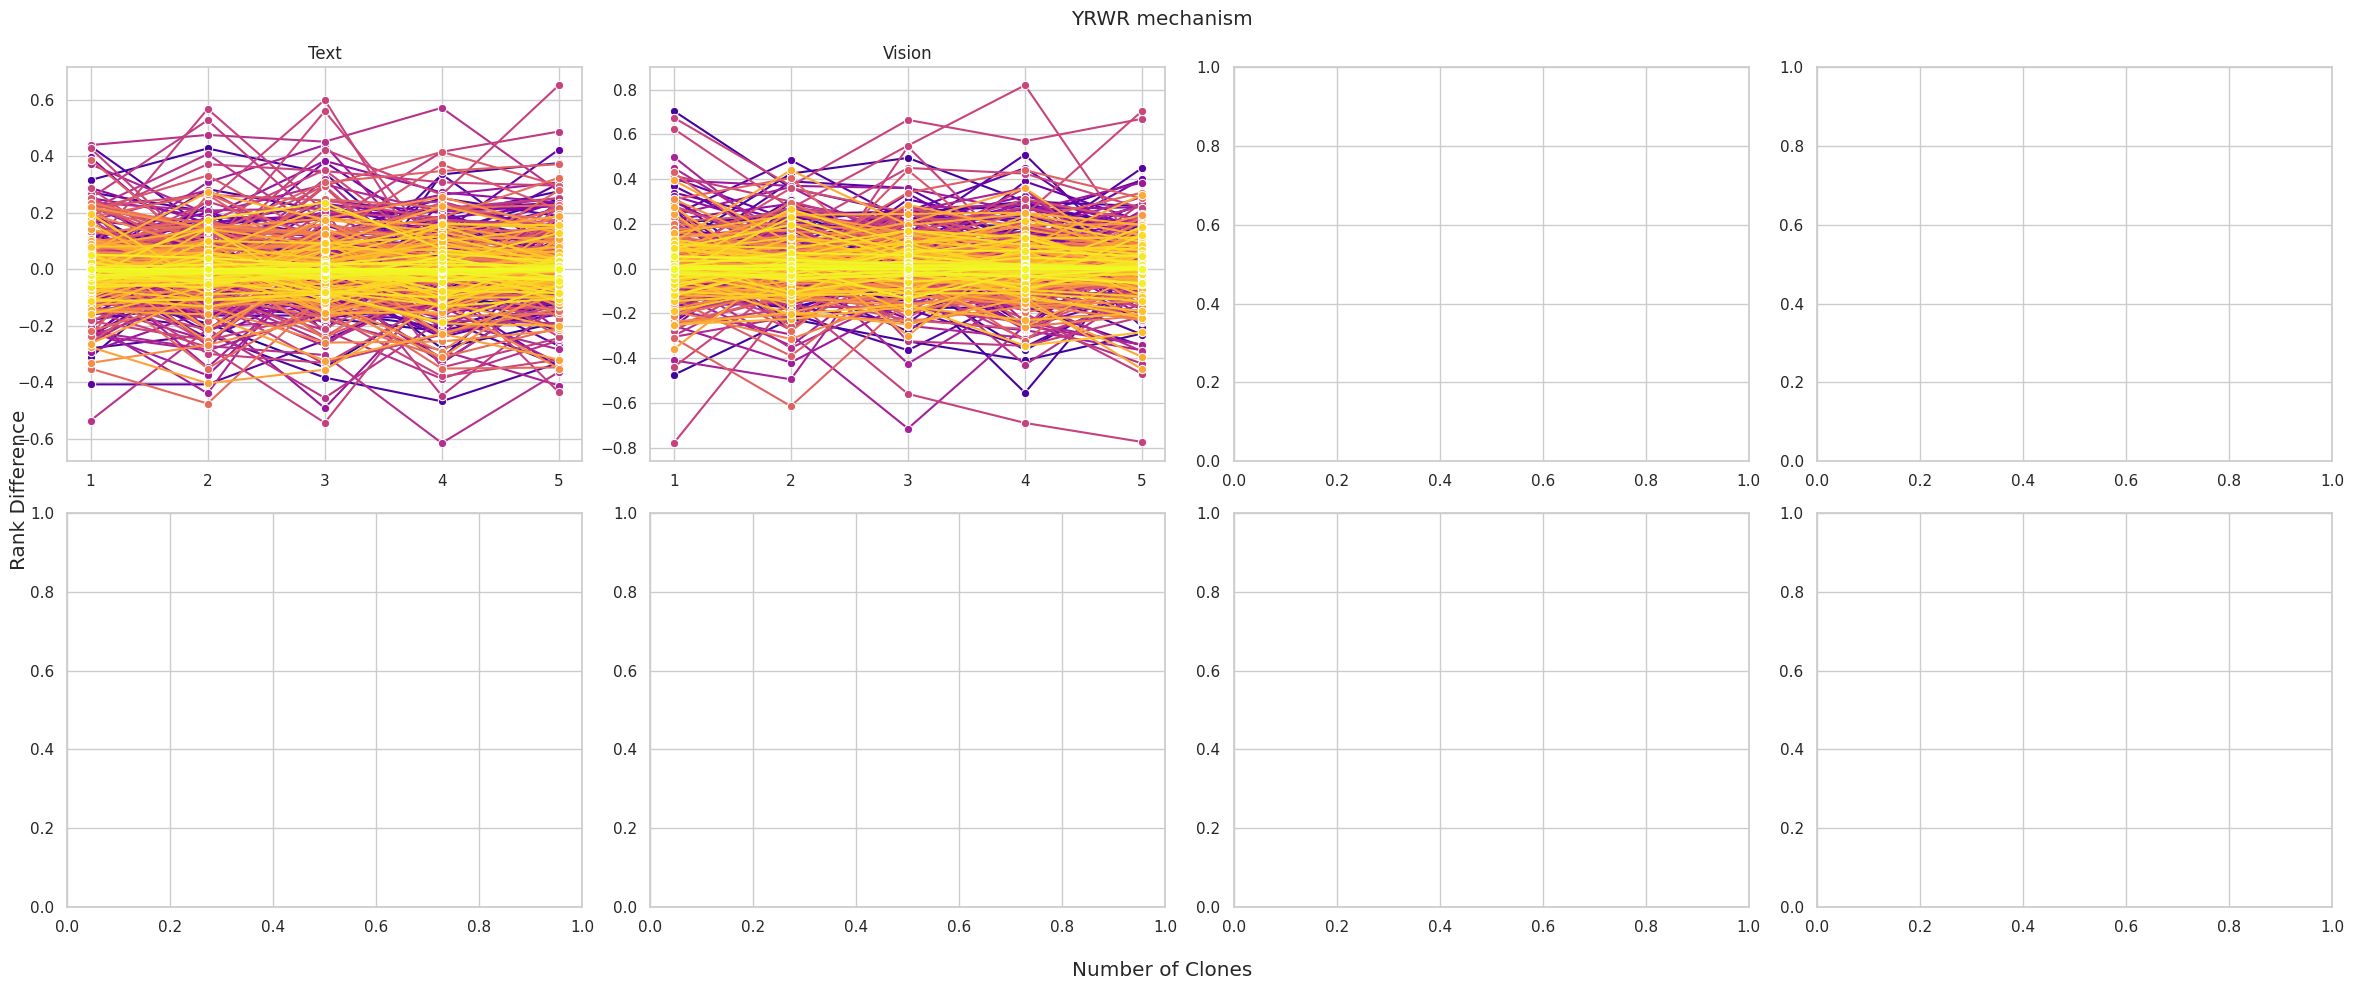

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    plot_rank_differences(df_yrwr_with_clone[type], df_yrwr_without_clone[type], axes[i//4, i%4], TYPE_NAMES[type])

fig.supxlabel("Number of Clones")
fig.supylabel("Rank Difference")
fig.suptitle("YRWR mechanism")
# axes[0, 0].legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

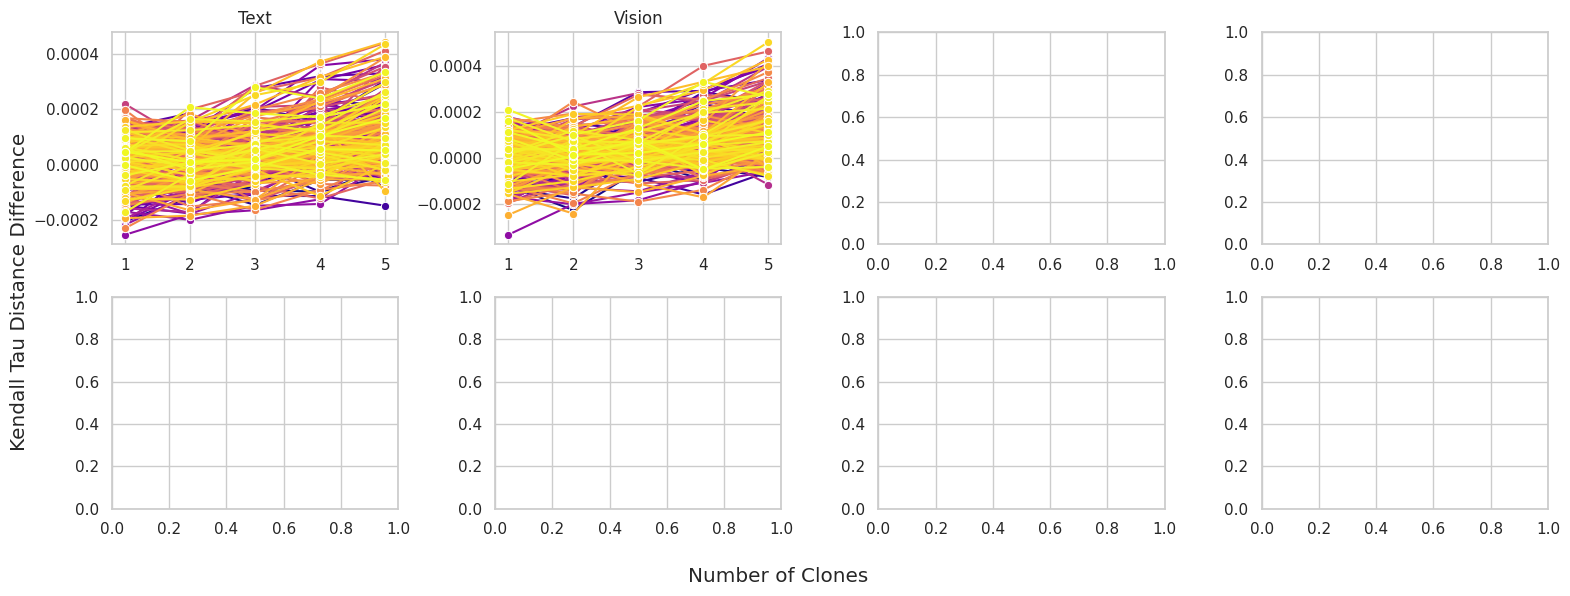

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    plot_rank_differences(df_kt_distance_with_clone[type], df_kt_distance_yrwr_with_clone[type], axes[i//4, i%4], TYPE_NAMES[type])

fig.supxlabel("Number of Clones")
fig.supylabel("Kendall Tau Distance Difference")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1231814/1854762200.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=90)


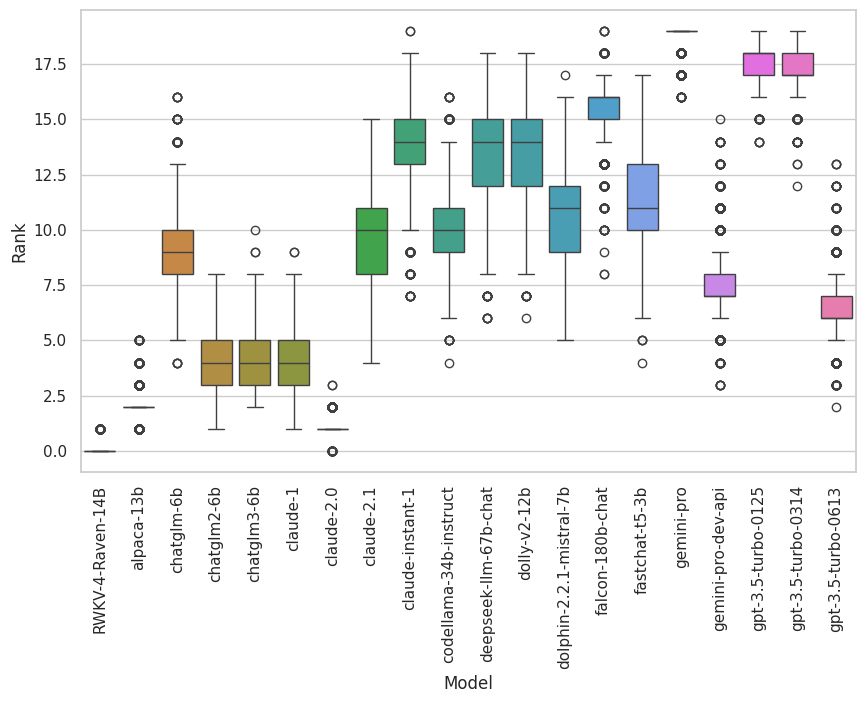

In [125]:
plot_ranks(df_without_clone)

# Arena Human Preference preprocessing

In [3]:
from rank_quality import fit_bt_model

In [4]:
df = pd.read_csv("hf://datasets/lmarena-ai/arena-human-preference-55k/train.csv")
df = df[df["winner_tie"] == 0]
df.loc[df["winner_model_a"] == 1, "winner"] = df["model_a"]
df.loc[df["winner_model_a"] == 0, "loser"] = df["model_a"]
df.loc[df["winner_model_b"] == 1, "winner"] = df["model_b"]
df.loc[df["winner_model_b"] == 0, "loser"] = df["model_b"]

In [5]:
all_models = pd.Index(df['winner'].unique()).union(df['loser'].unique())
win_counts = pd.DataFrame(np.zeros((len(all_models), len(all_models))), index=all_models, columns=all_models)
battle_counts = pd.DataFrame(np.zeros((len(all_models), len(all_models))), index=all_models, columns=all_models)

for _, row in df.iterrows():
    win_counts.loc[row['winner'], row['loser']] += 1
    battle_counts.loc[row['winner'], row['loser']] += 1
    battle_counts.loc[row['loser'], row['winner']] += 1

for i in range(len(all_models)):
    for j in range(i):
        if battle_counts.iloc[i, j] > 0:
            win_counts.iloc[i, j] = win_counts.iloc[i, j] / battle_counts.iloc[i, j]
            win_counts.iloc[j, i] = 1 - win_counts.iloc[i, j]
        else:
            win_counts.iloc[i, j] = np.nan
            win_counts.iloc[j, i] = np.nan
    win_counts.iloc[i, i] = np.nan
    battle_counts.iloc[i, i] = 0

bt_scores, _ = fit_bt_model(win_counts, battle_counts)
sorted_indices = np.argsort(bt_scores)[::-1]
win_counts = win_counts.iloc[sorted_indices, sorted_indices]
battle_counts = battle_counts.iloc[sorted_indices, sorted_indices]


win_counts.to_csv("parsed_heatmaps/ahp_win_rates.csv")
battle_counts.to_csv("parsed_heatmaps/ahp_battle_counts.csv")


In [ ]:
win_counts

,gpt-4-0125-preview,gpt-4-1106-preview,gpt-4-0314,gpt-4-0613,qwen1.5-72b-chat,mistral-medium,claude-1,claude-2.0,gemini-pro-dev-api,yi-34b-chat,...,mpt-7b-chat,alpaca-13b,RWKV-4-Raven-14B,chatglm2-6b,oasst-pythia-12b,fastchat-t5-3b,chatglm-6b,stablelm-tuned-alpha-7b,dolly-v2-12b,llama-13b
gpt-4-0125-preview,NaN,0.537313,0.583333,0.702381,1.000000,0.720339,0.818182,0.571429,0.571429,0.428571,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gpt-4-1106-preview,0.462687,NaN,0.751073,0.670134,0.538462,0.719243,0.683168,0.737968,0.706731,0.767442,...,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN
gpt-4-0314,0.416667,0.248927,NaN,0.509259,0.666667,0.604651,0.618750,0.680000,0.772727,0.384615,...,0.941176,0.926471,0.879310,NaN,0.906250,0.971831,0.906667,0.888889,1.000000,0.954545
gpt-4-0613,0.297619,0.329866,0.490741,NaN,0.545455,0.484615,0.600000,0.551220,0.566667,0.545455,...,1.000000,1.000000,0.777778,0.92,1.000000,0.857143,0.750000,NaN,1.000000,NaN
qwen1.5-72b-chat,0.000000,0.461538,0.333333,0.454545,NaN,0.615385,0.625000,0.500000,0.571429,0.652174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fastchat-t5-3b,NaN,NaN,0.028169,0.142857,NaN,NaN,0.080000,0.285714,NaN,NaN,...,0.423077,0.431818,0.444444,NaN,0.456522,NaN,0.542857,0.809524,0.666667,0.789474
chatglm-6b,NaN,NaN,0.093333,0.250000,NaN,NaN,0.096154,0.272727,NaN,NaN,...,0.217391,0.406250,0.487805,NaN,0.450980,0.457143,NaN,0.484848,0.400000,0.592593
stablelm-tuned-alpha-7b,NaN,NaN,0.111111,NaN,NaN,NaN,0.074074,NaN,NaN,NaN,...,0.176471,0.255814,0.275862,NaN,0.282609,0.190476,0.515152,NaN,0.538462,0.625000
dolly-v2-12b,NaN,NaN,0.000000,0.000000,NaN,NaN,0.035714,NaN,NaN,NaN,...,0.222222,0.282051,0.277778,NaN,0.321429,0.333333,0.600000,0.461538,NaN,0.555556


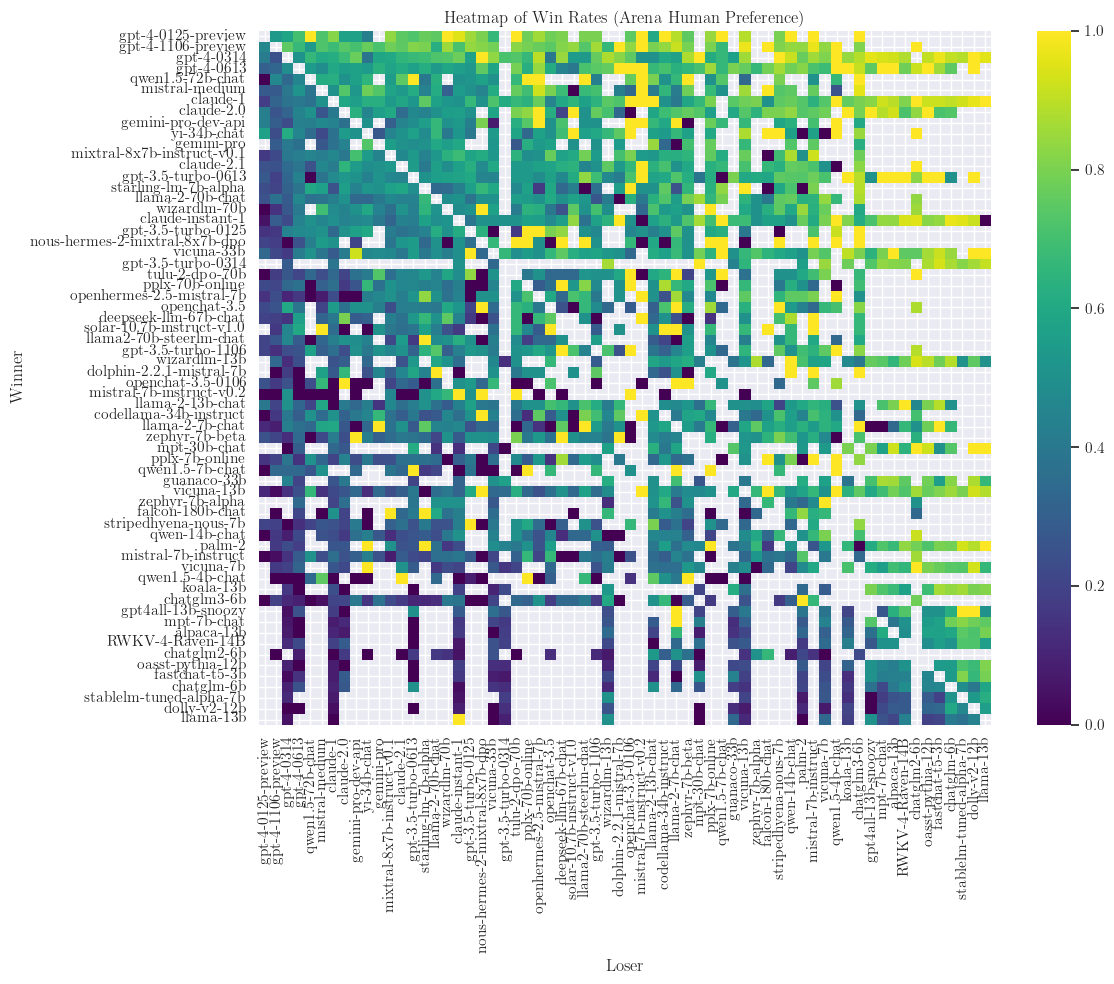

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(win_counts, cmap="viridis", annot=False, xticklabels=True, yticklabels=True)
plt.title("Heatmap of Win Rates (Arena Human Preference)")
plt.xlabel("Loser")
plt.ylabel("Winner")
plt.tight_layout()
plt.show()
